In [2]:
import pandas as pd
df= pd.read_csv("Advertising.csv")
print(df.head())
X = df[['TV']].values
y = df['Sales'].values

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit(X_train,y_train)
print(reg.intercept_, reg.coef_)
print(reg.predict(X_test))


7.007108428241857 [0.05548294]
[16.06747317 17.84847567 23.25806271  7.65625887 19.23000098 11.17387752
 19.03581067  9.78125562 19.34651516 16.72217191  8.75482116 10.12524988
 20.01785878  7.30671633 14.74697911 16.45030549  7.41213392 17.97053815
 11.18497411 20.17875932 19.74044406 10.76885203  9.1154603  20.92777906
 10.83543156  9.97544593 18.85271696 14.73588252 11.84522114  7.47316516
 18.09260063 10.84652815 18.04266598  7.94477018 22.58117079 20.22314567
  9.68693462 22.19279018 13.50970946  8.53288939]


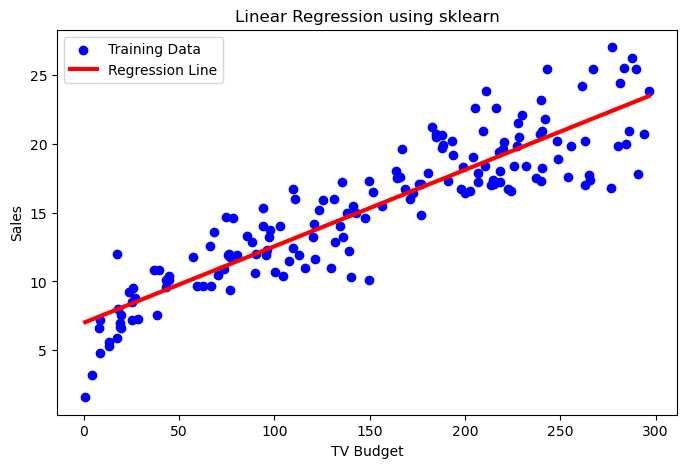

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

# Scatter plot of training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Generate x values for a smooth line
x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)

# Predict using the trained sklearn model
y_line = reg.predict(x_line)

# Plot regression line
plt.plot(x_line, y_line, color='red', linewidth=3, label='Regression Line')

plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("Linear Regression using sklearn")
plt.legend()
plt.show()

In [6]:
y_pred=reg.predict(X_test)
mse = np.mean((y_test - y_pred)**2)
print("MSE =", mse)

MSE = 6.101072906773963


In [7]:
rmse = np.sqrt(mse)
print("RMSE =", rmse)

RMSE = 2.470035001123256


In [8]:
mae = np.mean(np.abs(y_test - y_pred))
print("MAE =", mae)

MAE = 1.9502948931650086


In [9]:
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (ss_res/ss_tot)
print("R² =", r2)

R² = 0.802561303423698


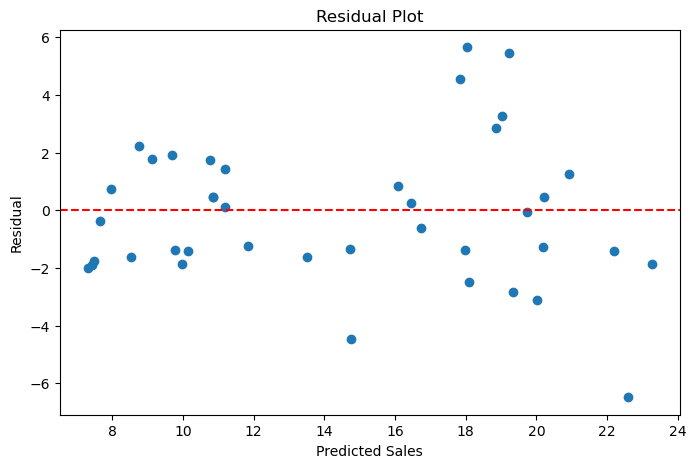

In [10]:
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0,
            color='red',
            linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [11]:
r_sq = reg.score(X, y)
print(f"coefficient of determination: {r_sq}")
print(f"intercept: {reg.intercept_}")
print(f"slope: {reg.coef_}")

coefficient of determination: 0.8121316219239643
intercept: 7.007108428241857
slope: [0.05548294]


In [12]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales'].values

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit(X_train,y_train)
print(reg.intercept_, reg.coef_)
print(reg.predict(X_test))


4.714126402214138 [0.05450927 0.10094536 0.00433665]
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475  8.92396497  8.4817344
 18.2075123   8.06750728 12.64550975 14.93162809  8.12814594 17.89876565
 11.00880637 20.47832788 20.80631846 12.59883297 10.9051829  22.38854775
  9.41796094  7.92506736 20.83908497 13.81520938 10.77080925  7.92682509
 15.95947357 10.63490851 20.80292008 10.43434164 21.5784752  21.18364487
 12.12821771 22.80953262 12.60992766  6.46441252]


In [15]:
y_pred=reg.predict(X_test)
mse = np.mean((y_test - y_pred)**2)
print("MSE =", mse)

MSE = 2.907756910271091


In [16]:
rmse = np.sqrt(mse)
print("RMSE =", rmse)

RMSE = 1.7052146229349228


In [17]:
mae = np.mean(np.abs(y_test - y_pred))
print("MAE =", mae)

MAE = 1.2748262109549338


In [18]:
r_sq = reg.score(X, y)
print(f"coefficient of determination: {r_sq}")
print(f"intercept: {reg.intercept_}")
print(f"slope: {reg.coef_}")

coefficient of determination: 0.901998798787734
intercept: 4.714126402214138
slope: [0.05450927 0.10094536 0.00433665]


In [19]:
import pandas as pd
df1=pd.read_csv("FuelConsumptionCo2.csv")

In [20]:
X = df1[['ENGINESIZE']].values
y = df1['CO2EMISSIONS'].values

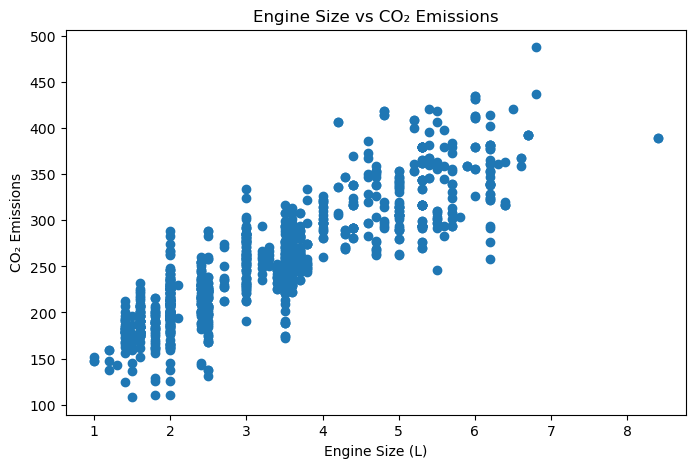

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.xlabel("Engine Size (L)")
plt.ylabel("CO₂ Emissions")
plt.title("Engine Size vs CO₂ Emissions")
plt.show()

In [22]:
X_poly = np.column_stack((
    np.ones(len(X)),
    X,
    X**2,
    X**3
))

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit(X_train,y_train)
print(reg.intercept_, reg.coef_)
print(reg.predict(X_test))


131.29858491942963 [ 0.         29.92154206  3.7724906  -0.41363227]
[312.31960641 264.50250823 268.60918714 243.8475551  202.92257324
 243.8475551  268.60918714 284.87213723 323.51452602 268.60918714
 268.60918714 376.71473631 252.1239209  264.50250823 268.60918714
 264.50250823 187.13639035 268.60918714 187.13639035 334.2716868
 323.51452602 194.96792674 252.1239209  272.70197128 243.8475551
 194.96792674 202.92257324 187.13639035 341.16683739 252.1239209
 337.74854562 219.12177916 194.96792674 323.51452602 243.8475551
 312.31960641 284.87213723 334.2716868  202.92257324 223.21750203
 187.13639035 187.13639035 179.44781841 223.21750203 284.87213723
 187.13639035 243.8475551  243.8475551  202.92257324 330.73874273
 363.24653189 268.60918714 202.92257324 272.70197128 243.8475551
 334.2716868  334.2716868  347.81779263 202.92257324 296.82790578
 284.87213723 296.82790578 300.75393639 268.60918714 187.13639035
 260.38441636 179.44781841 316.09574982 243.8475551  272.70197128
 323.5145260